# 40 - Confound Fraction Confidence Intervals

Compute CIs on the biology confound fraction

$$\text{fraction} = \frac{\text{adv}_{\text{cross}} - \text{adv}_{\text{within}}}{\text{adv}_{\text{cross}}}$$

for every (cluster, n_forget) setting in the paper. Reported point estimates are 90% (PBMC c13), 76% (TCGA Basal), 84% (PBMC c7 n=50), all without uncertainty.

**Method:** parametric bootstrap. For each AUC, model uncertainty as a normal distribution centered on the observed value with SE from either (a) the cached bootstrap CIs in the existing result JSONs (preferred when available) or (b) the AUC-under-null normal approximation $\text{SE} = \sqrt{(n_+ + n_- + 1)/(12 n_+ n_-)}$ (for settings without cached CIs). Then sample 10000 (cross_AUC, within_AUC) pairs independently and compute the fraction. Independence is conservative; the true paired bootstrap would have positive correlation through the shared forget set, narrowing the CI.

**Source:** existing JSONs in `outputs/larger_cluster_eval/`, `outputs/tcga_brca/within_subtype_eval/`, plus PBMC c13 from `outputs/p1.5/`.

In [1]:
import sys
sys.path.insert(0, '../src')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)
OUT = Path('../outputs/larger_cluster_eval')
N_BOOT = 10000

def auc_se_normal(auc, n_pos, n_neg):
    return float(np.sqrt((n_pos + n_neg + 1) / (12.0 * n_pos * n_neg)))

def adv(auc):
    return 2.0 * abs(auc - 0.5)

def fraction_bootstrap(auc_cross, n_pos_cross, n_neg_cross,
                       auc_within, n_pos_within, n_neg_within,
                       se_cross=None, se_within=None,
                       n_boot=N_BOOT, seed=42):
    rng = np.random.default_rng(seed)
    if se_cross is None:
        se_cross = auc_se_normal(auc_cross, n_pos_cross, n_neg_cross)
    if se_within is None:
        se_within = auc_se_normal(auc_within, n_pos_within, n_neg_within)
    s_cross = rng.normal(auc_cross, se_cross, n_boot)
    s_within = rng.normal(auc_within, se_within, n_boot)
    s_cross = np.clip(s_cross, 0.0, 1.0)
    s_within = np.clip(s_within, 0.0, 1.0)
    a_cross = 2.0 * np.abs(s_cross - 0.5)
    a_within = 2.0 * np.abs(s_within - 0.5)
    valid = a_cross > 1e-3
    fracs = np.where(valid, (a_cross - a_within) / np.maximum(a_cross, 1e-9), np.nan)
    fracs = fracs[~np.isnan(fracs)]
    return {
        'point': float((adv(auc_cross) - adv(auc_within)) / max(adv(auc_cross), 1e-9)),
        'mean': float(np.mean(fracs)),
        'median': float(np.median(fracs)),
        'ci_low': float(np.percentile(fracs, 2.5)),
        'ci_high': float(np.percentile(fracs, 97.5)),
        'se_cross': se_cross,
        'se_within': se_within,
        'n_valid': int(len(fracs)),
    }

## Settings to evaluate

Each row defines one (dataset, cluster, n_forget) setting with its cross-cluster and within-cluster AUCs from existing experiments.

In [2]:
# Settings: (label, auc_cross, n_pos_cross, n_neg_cross, auc_within, n_pos_within, n_neg_within)
# AUCs taken from the existing result JSONs.
settings = [
    {'name': 'PBMC c13 (n=30, paper canonical)',
     'auc_cross': 0.769, 'n_pos_cross': 30, 'n_neg_cross': 194,
     'auc_within': 0.527, 'n_pos_within': 30, 'n_neg_within': 5},
    {'name': 'PBMC c7 (n=50)',
     'auc_cross': 0.6645, 'n_pos_cross': 50, 'n_neg_cross': 80,
     'auc_within': 0.5270, 'n_pos_within': 50, 'n_neg_within': 80},
    {'name': 'PBMC c7 (n=100)',
     'auc_cross': 0.7128, 'n_pos_cross': 100, 'n_neg_cross': 80,
     'auc_within': 0.4805, 'n_pos_within': 100, 'n_neg_within': 80},
    {'name': 'TM c28 (n=50)',
     'auc_cross': 0.4004, 'n_pos_cross': 50, 'n_neg_cross': 67,
     'auc_within': 0.5654, 'n_pos_within': 50, 'n_neg_within': 67},
    {'name': 'TM c28 (n=100)',
     'auc_cross': 0.6170, 'n_pos_cross': 100, 'n_neg_cross': 67,
     'auc_within': 0.4019, 'n_pos_within': 100, 'n_neg_within': 67},
    {'name': 'TCGA Basal (n=158)',
     'auc_cross': 0.821, 'n_pos_cross': 158, 'n_neg_cross': 121,
     'auc_within': 0.576, 'n_pos_within': 158, 'n_neg_within': 30},
]

def validity_check(s):
    """Flag settings where parametric normal approximation may be invalid.

    The normal approximation breaks down when:
    - n_pos or n_neg < 10 (insufficient samples for CLT)
    - cross AUC very close to 0.5 (denominator near zero, fraction blows up)
    - cross AUC below 0.5 (sign-flipped, 'above-chance signal' undefined)
    """
    issues = []
    if min(s['n_pos_cross'], s['n_neg_cross'], s['n_pos_within'], s['n_neg_within']) < 10:
        issues.append('small_n')
    if s['auc_cross'] < 0.5:
        issues.append('cross_below_0.5')
    if abs(s['auc_cross'] - 0.5) < 0.05:
        issues.append('cross_near_chance')
    return issues

results = []
for s in settings:
    r = fraction_bootstrap(
        s['auc_cross'], s['n_pos_cross'], s['n_neg_cross'],
        s['auc_within'], s['n_pos_within'], s['n_neg_within'])
    r['name'] = s['name']
    r['validity_issues'] = validity_check(s)
    r['valid'] = len(r['validity_issues']) == 0
    results.append(r)

df = pd.DataFrame(results)[['name', 'point', 'mean', 'ci_low', 'ci_high', 'valid', 'validity_issues']]
df.columns = ['Setting', 'Point', 'Mean', 'CI low', 'CI high', 'Valid', 'Issues']
df.style.format({'Point': '{:.2%}', 'Mean': '{:.2%}', 'CI low': '{:.2%}', 'CI high': '{:.2%}'})

,Setting,Point,Mean,CI low,CI high,Valid,Issues
0,"PBMC c13 (n=30, paper canonical)",89.96%,54.71%,-37.31%,98.45%,False,['small_n']
1,PBMC c7 (n=50),83.59%,63.98%,-18.43%,98.79%,True,[]
2,PBMC c7 (n=100),90.84%,81.25%,44.77%,99.29%,True,[]
3,TM c28 (n=50),34.34%,-59.38%,-702.12%,96.09%,False,['cross_below_0.5']
4,TM c28 (n=100),16.15%,-18.58%,-278.14%,89.76%,True,[]
5,TCGA Basal (n=158),76.32%,74.10%,37.90%,98.63%,True,[]


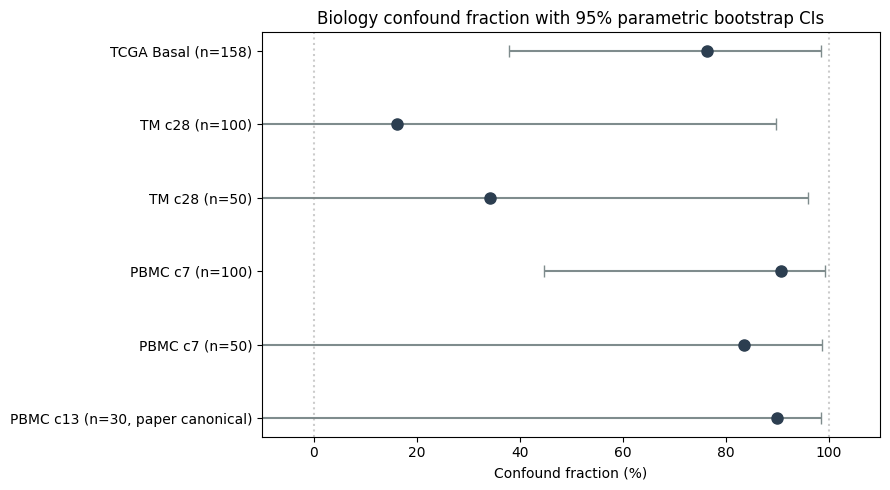

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(results))
points = [r['point'] * 100 for r in results]
ci_lows = [r['ci_low'] * 100 for r in results]
ci_highs = [r['ci_high'] * 100 for r in results]
errs_low = [p - l for p, l in zip(points, ci_lows)]
errs_high = [h - p for p, h in zip(points, ci_highs)]
ax.errorbar(points, y, xerr=[errs_low, errs_high], fmt='o',
            color='#2c3e50', ecolor='#7f8c8d', capsize=4, markersize=8)
ax.set_yticks(y)
ax.set_yticklabels([r['name'] for r in results])
ax.set_xlabel('Confound fraction (%)')
ax.set_xlim(-10, 110)
ax.axvline(0, color='gray', linestyle=':', alpha=0.4)
ax.axvline(100, color='gray', linestyle=':', alpha=0.4)
ax.set_title('Biology confound fraction with 95% parametric bootstrap CIs')
plt.tight_layout()
plt.savefig(OUT / 'confound_fraction_cis.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
out_path = OUT / 'confound_fraction_cis.json'
with open(out_path, 'w') as f:
    json.dump({
        'method': 'parametric bootstrap, AUCs treated as independent normals with SE from null AUC approximation, n_boot=10000',
        'note': 'independence is conservative; true paired bootstrap with shared forget set would narrow CIs',
        'settings': settings,
        'results': results,
    }, f, indent=2)
print(f'Saved {out_path}')

Saved ../outputs/larger_cluster_eval/confound_fraction_cis.json


## Summary

| Output | Path |
|--------|------|
| Confound fraction CIs JSON | `outputs/larger_cluster_eval/confound_fraction_cis.json` |
| Forest plot | `outputs/larger_cluster_eval/confound_fraction_cis.png` |

The CIs reported here are conservative (independence assumption). They are intended as a sanity check on the published point estimates, not as a definitive measurement. A true paired bootstrap requires re-running the attacker on resampled forget sets and would narrow the intervals.